Data klasörünün içinde UCMERCED datasetinde klasörler train/valid/test şeklinde ayrılmamış. Ayrıca NWPU datasetinde ise sadece train ve test klasörü var,valid klasörü yok. 

önceliğimiz bunu düzeltmek olacak.
Doğru klasörleme yapısına böldüğümüz datasetleri "split_data" klasöründe olacak.


In [1]:
#split-folders kütüphanesi sayesinde veri setimizi train,val ve test olarak ayırabiliriyoruz.
%pip install split-folders

import splitfolders

#UCMERCED veri setimizi yüzde 70 train, yüzde 10 validation ve yüzde 20 test olarak ayırıyoruz.
splitfolders.ratio("../data/ucmerced/Images",output="../split_data/ucmerced",seed=42,ratio=(0.7,0.1,0.2))

#NWPU veri setimizin train kısmının yüzde 80 train, yüzde 20 validation olarak ayırıyoruz.Test verisi zaten olduğu için ellemiyoruz.
splitfolders.ratio("../data/nwpu/train/train",output="../split_data/nwpu",seed=42,ratio=(0.8,0.2))


Note: you may need to restart the kernel to use updated packages.


##Veri setlerininin analizi

In [2]:
import torch 
from torchvision.datasets import ImageFolder

#veri setleriinin yollarını tanımlıyoruz.

nwpu_train_path = "../split_data/nwpu/train"
nwpu_val_path = "../split_data/nwpu/val"
nwpu_test_path = "../split_data/nwpu/test"

ucmerced_train_path = "../split_data/ucmerced/train"
ucmerced_val_path = "../split_data/ucmerced/val"
ucmerced_test_path = "../split_data/ucmerced/test"
###############
#NWPU veri seti ile ilgili bilgiler


#nwpu train verisi için kullanılacak transform işlemleri
from torchvision import transforms

nwpu_train_tranform= transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],[0.229, 0.224, 0.225])


])

#nwpu test ve validasyon verisi için kullanılacak transform işlemleri
nwpu_test_tranform= transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],[0.229, 0.224, 0.225])


])

#ucmerced train verisi için kullanılacak transform işlemleri

ucmerced_train_tranform= transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],[0.229, 0.224, 0.225])


])

#ucmerced test,validasyon verisi için kullanılacak transform işlemleri

ucmerced_test_tranform= transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],[0.229, 0.224, 0.225])


])





#Image Folder (görsel,sınıf) şeklinde tuple veri verir

nwpu_train = ImageFolder(nwpu_train_path,transform=nwpu_train_tranform)
nwpu_val = ImageFolder(nwpu_val_path,transform=nwpu_test_tranform)
nwpu_test = ImageFolder(nwpu_test_path,transform=nwpu_test_tranform)
nwpu_toplam_resim_sayisi = len(nwpu_val)+ len(nwpu_train) +len(nwpu_test)
nwpu_siniflar = nwpu_train.classes

print(f"NWPU verisinde toplamda {nwpu_toplam_resim_sayisi} gorsel icermektedir")
print(f"NWPU verisinde train için {len(nwpu_train)} tane görsel var")
print(f"NWPU verisinde validasyon için {len(nwpu_val)} tane görsel var")
print(f"NWPU verisinde test için {len(nwpu_test)} tane görsel var")
print(f"NWPU verisindeki toplam sinif sayisi {len(nwpu_train.classes)}")
print(f"NWPU verisindeki siniflar {nwpu_siniflar}")

print("*-*"*20)




nwpu_sinif_indexleri = nwpu_train.class_to_idx


nwpu_sinif_indexleri.values() #mwpu veri setindeki her sınıfın index sayısını verir

nwpu_train_list=list(nwpu_train)



for index in nwpu_sinif_indexleri.values():
    sayac=0

    for i in nwpu_train_list:

        if i[1] == index :
                sayac+=1
    print(f"NWPU verisetinde {index+1}.nci siniftaki toplam train eleman sayisi {sayac}")
    sayac=0




NWPU verisinde toplamda 31500 gorsel icermektedir
NWPU verisinde train için 21600 tane görsel var
NWPU verisinde validasyon için 5400 tane görsel var
NWPU verisinde test için 4500 tane görsel var
NWPU verisindeki toplam sinif sayisi 45
NWPU verisindeki siniflar ['airplane', 'airport', 'baseball_diamond', 'basketball_court', 'beach', 'bridge', 'chaparral', 'church', 'circular_farmland', 'cloud', 'commercial_area', 'dense_residential', 'desert', 'forest', 'freeway', 'golf_course', 'ground_track_field', 'harbor', 'industrial_area', 'intersection', 'island', 'lake', 'meadow', 'medium_residential', 'mobile_home_park', 'mountain', 'overpass', 'palace', 'parking_lot', 'railway', 'railway_station', 'rectangular_farmland', 'river', 'roundabout', 'runway', 'sea_ice', 'ship', 'snowberg', 'sparse_residential', 'stadium', 'storage_tank', 'tennis_court', 'terrace', 'thermal_power_station', 'wetland']
*-**-**-**-**-**-**-**-**-**-**-**-**-**-**-**-**-**-**-**-*
NWPU verisetinde 1.nci siniftaki toplam

In [3]:
from torchvision.datasets import ImageFolder

#Image Folder (görsel,sınıf) şeklinde tuple verir

ucmerced_train = ImageFolder(ucmerced_train_path,transform=ucmerced_train_tranform)
ucmerced_val = ImageFolder(ucmerced_val_path,transform=ucmerced_test_tranform)
ucmerced_test = ImageFolder(ucmerced_test_path,transform=ucmerced_test_tranform)
ucmerced_toplam_resim_sayisi = len(ucmerced_val)+ len(ucmerced_train) +len(ucmerced_test)
ucmerced_siniflar = ucmerced_train.classes

###############
#NWPU veri seti ile ilgili bilgiler

print(f"UCMERCED verisinde toplamda {ucmerced_toplam_resim_sayisi} gorsel icermektedir")
print(f"UCMERCED verisinde train için {len(ucmerced_train)} tane görsel var")
print(f"UCMERCED verisinde validasyon için {len(ucmerced_val)} tane görsel var")
print(f"UCMERCED verisinde test için {len(ucmerced_test)} tane görsel var")
print(f"UCMERCED verisindeki toplam sinif sayisi {len(ucmerced_train.classes)}")
print(f"UCMERCED verisindeki siniflar {ucmerced_siniflar}")
print("*-*"*20)




#ucmerced veri setindeki her sınıfın index sayısını verir
ucmerced_sinif_indexleri = ucmerced_train.class_to_idx.values()

ucmerced_train_list=list(ucmerced_train)


for index in ucmerced_sinif_indexleri:
    sayac=0

    for i in ucmerced_train_list:

        if i[1] == index :
                sayac+=1
    print(f"UCMERCED verisetinde {index+1}.nci siniftaki toplam train eleman sayisi {sayac}")
    sayac=0


UCMERCED verisinde toplamda 2520 gorsel icermektedir
UCMERCED verisinde train için 1680 tane görsel var
UCMERCED verisinde validasyon için 420 tane görsel var
UCMERCED verisinde test için 420 tane görsel var
UCMERCED verisindeki toplam sinif sayisi 21
UCMERCED verisindeki siniflar ['agricultural', 'airplane', 'baseballdiamond', 'beach', 'buildings', 'chaparral', 'denseresidential', 'forest', 'freeway', 'golfcourse', 'harbor', 'intersection', 'mediumresidential', 'mobilehomepark', 'overpass', 'parkinglot', 'river', 'runway', 'sparseresidential', 'storagetanks', 'tenniscourt']
*-**-**-**-**-**-**-**-**-**-**-**-**-**-**-**-**-**-**-**-*
UCMERCED verisetinde 1.nci siniftaki toplam train eleman sayisi 80
UCMERCED verisetinde 2.nci siniftaki toplam train eleman sayisi 80
UCMERCED verisetinde 3.nci siniftaki toplam train eleman sayisi 80
UCMERCED verisetinde 4.nci siniftaki toplam train eleman sayisi 80
UCMERCED verisetinde 5.nci siniftaki toplam train eleman sayisi 80
UCMERCED verisetinde 6

##Veri setlerindeki görüntüler ve görüntü özellikleri

<bound method Image.getpixel of <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=256x256 at 0x13A6E9BA0>>


Text(0.5, 1.0, 'parking_lot')

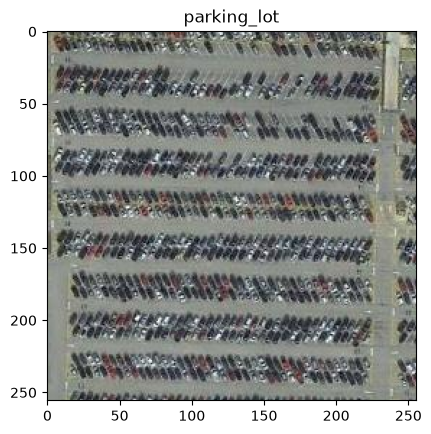

In [4]:
#nwpu train verisetindeki rastgele seçilen görüntünün özellikleri
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path
import random

nwpu_resim_yolu=Path(nwpu_train_path)
nwpu_train_resimleri_listesi=list(nwpu_resim_yolu.glob("*/*.jpg"))

nwpu_train_rastgele_resim_yolu= random.choice(nwpu_train_resimleri_listesi)

#nwpu train verisinden rastgele görsel çekerek görsel hakkında bilgi veriyor
#görsel 256x256 piksel ve RGB(Red,Green,Blue) yani 3 renk kanalınsa sahip
print(Image.open(nwpu_train_rastgele_resim_yolu).getpixel)

plt.imshow(Image.open(nwpu_train_rastgele_resim_yolu))
plt.title(nwpu_train_rastgele_resim_yolu.parent.stem)



<bound method Image.getpixel of <PIL.TiffImagePlugin.TiffImageFile image mode=RGB size=256x256 at 0x13BE8BB10>>


Text(0.5, 1.0, 'denseresidential')

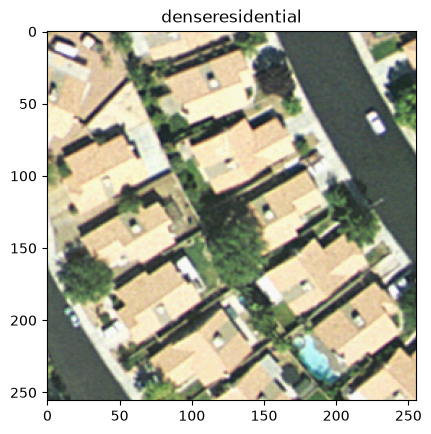

In [5]:
#ucmerced veri setindeki rastgele seçilen görüntünün özellikleri
import random
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path


ucmerced_resim_yolu = Path(ucmerced_train_path)

ucmerced_train_resimleri_listesi = list(ucmerced_resim_yolu.glob("*/*.tif"))
ucmerced_train_rastgele_resim_yolu=random.choice(ucmerced_train_resimleri_listesi)

#ucmerced train verisinden rastgele görsel çekerek görsel hakkında bilgi veriyor
#görsel 256x256 piksel ve RGB(Red,Green,Blue) yani 3 renk kanalınsa sahip
print(Image.open(ucmerced_train_rastgele_resim_yolu).getpixel)

plt.imshow(Image.open(ucmerced_train_rastgele_resim_yolu))
plt.title(ucmerced_train_rastgele_resim_yolu.parent.stem)


##verileri modele vermek için DataLoader formatına getirmemiz gerekiyor

In [6]:
from torch.utils.data import DataLoader

#nwpu verisetindeki train,validasyon ve test verileri için DataLoder objeleri oluşturuldu

nwpu_train_loader=DataLoader(dataset=nwpu_train,batch_size=16,shuffle=True)
nwpu_valid_loader=DataLoader(dataset=nwpu_val,batch_size=16,shuffle=False)
nwpu_test_loader=DataLoader(dataset=nwpu_test,batch_size=16,shuffle=False)

#ucmerced verisetindeki train,validasyon ve test verileri için DataLoder objeleri oluşturuldu

ucmerced_train_loader = DataLoader(dataset=ucmerced_train,batch_size=16,shuffle=True)
ucmerced_valid_loader = DataLoader(dataset=ucmerced_val,batch_size=16,shuffle=False)
ucmerced_test_loader = DataLoader(dataset=ucmerced_test,batch_size=16,shuffle=True)



